In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchmetrics.regression import R2Score
from train_ODE_and_parametrization import NN_ODE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Precip Prediction

In [ ]:
# Load Z data
#XZ_train = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260129150710_global_ocean_land_rp=False_Ztrain_ConvNN+AE+D_tp=20_wd=0.0.npy')
#XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260129150710_global_ocean_land_rp=False_Zval_ConvNN+AE+D_tp=20_wd=0.0.npy')
#XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260417112208_global_ocean_land_rp=False_Ztest_ConvNN+AE+D_tp=20_wd=None.npy')
#XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260417112208_global_ocean_land_rp=False_Zval_ConvNN+AE+D_tp=20_wd=None.npy')
XZ_train = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260507185408_global_ocean_land_rp=False_Ztrain_ConvNN+AE+D_tp=20_wd=0.0.npy')
XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260507185408_global_ocean_land_rp=False_Zval_ConvNN+AE+D_tp=20_wd=0.0.npy')
XZ_test = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260507185408_global_ocean_land_rp=False_Ztest_ConvNN+AE+D_tp=20_wd=0.0.npy')

In [ ]:
# Load baseline run to get the missing forcings
onlyX_train = np.load('Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20260507154339_global_ocean_land_rp=False_Ztrain_NNbase_tp=0_wd=0.0.npy')
onlyX_val = np.load('Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20260507154339_global_ocean_land_rp=False_Zval_NNbase_tp=0_wd=0.0.npy')
onlyX_test = np.load('Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20260507154339_global_ocean_land_rp=False_Ztest_NNbase_tp=0_wd=0.0.npy')

In [ ]:
onlyX_train = onlyX_train[XZ_train[:, 0, 0].astype(int)]
onlyX_val = onlyX_val[XZ_val[:, 0, 0].astype(int)]
onlyX_test = onlyX_test[XZ_val[:, 0, 0].astype(int)]

In [ ]:
onlyX = np.concat((onlyX_train, onlyX_val, onlyX_test), axis=1)
del onlyX_train, onlyX_val, onlyX_test

In [ ]:

# Add four empty columns to the last dimension
X_emptyZ_val = np.concatenate((onlyX, np.zeros((onlyX.shape[0], onlyX.shape[1], 4))), axis=-1)
del onlyX

In [ ]:
X_emptyZ_val.shape

(81920, 2976, 14)

In [ ]:
xp_inds = [1, 2, 3, 4, 5, 6, 7, 8]
latent_dims = 4
# XP_train = torch.tensor(XZ_train[:, :, xp_inds], dtype=torch.float32, device=device)
# XP_val = torch.tensor(XZ_val[:, :, xp_inds], dtype=torch.float32, device=device)
# XP_test = torch.tensor(XZ_test[:, :, xp_inds], dtype=torch.float32, device=device)
# Z_train = torch.tensor(XZ_train[:, :, -latent_dims:], dtype=torch.float32, device=device)
# Z_val = torch.tensor(XZ_val[:, :, -latent_dims:], dtype=torch.float32, device=device)
# Z_test = torch.tensor(XZ_test[:, :, -latent_dims:], dtype=torch.float32, device=device)

# Create merged dataset of val and train, along temporal dimension
XP_emptyZ_val = torch.tensor(X_emptyZ_val[:, :, xp_inds], dtype=torch.float32, device=device)
Z_emptyZ_val = torch.tensor(X_emptyZ_val[:, :, -latent_dims:], dtype=torch.float32, device=device)
# XP_merged = torch.cat((XP_train, XP_emptyZ_val), dim=1)
# Z_merged = torch.cat((Z_train, Z_emptyZ_val), dim=1)
XP_merged = XP_emptyZ_val
Z_merged = Z_emptyZ_val
del XP_emptyZ_val, Z_emptyZ_val, X_emptyZ_val

In [ ]:
print(XP_merged.shape)
print(Z_merged.shape)

torch.Size([81920, 2976, 8])
torch.Size([81920, 2976, 4])


In [ ]:
t_rollout = 2975
# tmax_train = XP_train.shape[1]
# tmax_val = XP_val.shape[1]
# tmax_test = XP_test.shape[1]
tmax_merged = XP_merged.shape[1]
# t_prediction_train = np.arange(start=t_rollout, stop=tmax_train, step=t_rollout)
# t_prediction_val = np.arange(start=t_rollout, stop=tmax_val, step=t_rollout)
# t_prediction_test = np.arange(start=t_rollout, stop=tmax_test, step=t_rollout)
t_prediction_merged = np.arange(start=t_rollout, stop=tmax_merged, step=t_rollout)
coords = np.arange(XP_merged.shape[0], step=1)
#coords = np.array([123])
# XP_batch = XP_train[coords] # grab batch
# Z_batch = Z_train[coords]
# Z_batch = torch.zeros_like(Z_batch)  
# XP_batch = XP_merged[coords] # grab batch
# Z_batch = Z_merged[coords]


In [ ]:
Ncoords = XP_merged.shape[0]
Ncoords // 5

16384

In [ ]:
t_rollout

2975

In [ ]:
%load_ext autoreload
%autoreload 2
from train_ODE_and_parametrization import NN_ODE
def load_NNODE_checkpoint(path):
    checkpoint = torch.load(path, weights_only=False, map_location=device)
    model = NN_ODE(**checkpoint['model_kwargs'])
    model.ODE.load_state_dict(checkpoint['ODE_state'], )
    model.neural_net.load_state_dict(checkpoint['NN_state'])
    model.set_metadata(checkpoint['metadata'])

    return model

# path = 'networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260318180651.pkl'
path = 'networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260511173500_nonlinear_4d_corrected_00_timesteps_0.pkl'
#path = 'networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260511163124_nonlinear_4d_corrected_00_timesteps.pkl'
model_nonlin = load_NNODE_checkpoint(path)
path = 'nonlinear_ODE_residual_approach_4d_sympy_equations.pkl'
model_residual_nonlin = load_NNODE_checkpoint(path)

# path = 'networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260407224011_nonlinear_residual.pkl'
# model_resnonlin = load_NNODE_checkpoint(path)
path = 'networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260508202548_linear_4d_corrected_00_timesteps.pkl'
model_lin = load_NNODE_checkpoint(path)

In [ ]:
Pr_lins = []
Pr_pred_lins = []
Nbatches = 5
for i in range(1, Nbatches + 1):
    print(f'Batch {i}')
    coords_subset = coords[(i-1) * Ncoords//Nbatches: i*Ncoords//Nbatches]
    XP_batch = XP_merged[coords_subset] # grab batch
    Z_batch = Z_merged[coords_subset]
    Pr_lin, Pr_pred_lin = model_lin.forward(coords_subset, XP_batch, Z_batch, t_prediction_merged, t_rollout)
    Pr_lins.append(Pr_lin.cpu().detach().numpy().reshape(t_rollout, -1).T)  # Reshape back to (N_coords, N_timesteps)
    Pr_pred_lins.append(Pr_pred_lin.cpu().detach().numpy().reshape(t_rollout, -1).T)  # Reshape back to (N_coords, N_timesteps)

Batch 1
Batch 2
Batch 3
Batch 4
Batch 5


In [ ]:
Pr_lins = np.concatenate(Pr_lins, axis=0)
Pr_pred_lins = np.concatenate(Pr_pred_lins, axis=0)

In [ ]:
Pr_lins.shape

(81920, 2975)

In [ ]:
Pr_nonlin, Pr_pred_nonlin = model_nonlin.forward(coords, XP_batch, Z_batch, t_prediction_val, t_rollout)

In [ ]:
Pr_resnonlin, Pr_pred_resnonlin = model_resnonlin.forward(coords, XP_batch, Z_batch, t_prediction_val, t_rollout)

In [ ]:
t_spinup = 30
print('linear model R^2', R2Score()(torch.tensor(Pr_pred_lins[:, t_spinup:]).flatten(), torch.tensor(Pr_lins[:, t_spinup:]).flatten()).item())
# print('nonlinear model R^2', R2Score()(Pr_pred_nonlin, Pr_nonlin).item())
# print('residual nonlinear model R^2', R2Score()(Pr_pred_resnonlin, Pr_resnonlin).item())

linear model R^2 0.6402418613433838


In [ ]:
Pr_pred_lins.shape

(81920, 373)

(0.0, 0.2)

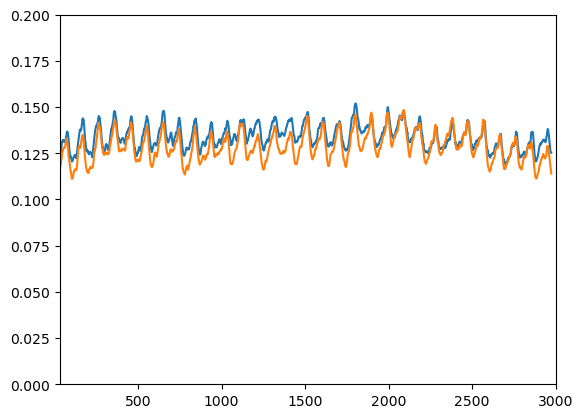

In [ ]:
plt.plot(np.mean(Pr_pred_lins, axis=0))
plt.plot(np.mean(Pr_lins, axis=0))
plt.xlim(t_spinup, 3000)
plt.ylim(0, .2)

In [ ]:
numpyrize = lambda x: x.cpu().detach().numpy()

In [ ]:
Pr_combined = np.array([Pr_pred_lins, Pr_lins])
np.save('precip_ODE_predictions/20260518121043_Pr_combined_merged_linear_ODE_latent_dims=4_tp=20_global_oceanland.npy', Pr_combined)

In [ ]:
Pr_combined = np.array([numpyrize(Pr_pred_resnonlin).flatten(), numpyrize(Pr_resnonlin).flatten()])
np.save('20260327125800_Pr_combined_residual_nonlinear_ODE_latent_dims=4_complexity=5p10_tp=20_global_oceanland.npy', Pr_combined)

In [ ]:
Pr_combined = np.array([numpyrize(Pr_pred_nonlin).flatten(), numpyrize(Pr_nonlin).flatten()])
np.save('20260327125800_Pr_combined_nonlinear_ODE_latent_dims=4_tp=20_global_oceanland.npy', Pr_combined)